In [3]:
import numpy as np
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import os
import random
from scipy.stats import spearmanr, pearsonr
import torch

In [4]:
amino_acid = np.load('./model/categorical_variables.npy', allow_pickle=True)


num_aa = len(amino_acid)
ohe = np.load('./data/x_test.npy', allow_pickle=True)

seq_len = np.load('./data/len_test.npy', allow_pickle=True)
seq_len = seq_len.astype(int)

imp = np.load('./model/importance_test.npy', allow_pickle=True)
prop = np.load('./data/y_test.npy', allow_pickle=True)
classes = np.argmax(ohe, axis=2)

In [5]:
# Convert one-hot encoded sequences back to amino acid sequences
sequence_list = []
for i in range(ohe.shape[0]):
    seq = ''
    for j in range(seq_len[i]):
        aa_index = np.argmax(ohe[i, j])
        seq += amino_acid[aa_index]
    sequence_list.append(seq)

print (sequence_list[:5])  # Print first 5 sequences to verify

['GIGKWLHSAKKFGKAFVGEIMNS', 'TCRSSGRYCRSPYDRRRRACRRITDACV', 'RIAGLAANFLPQILCKIARKC', 'TCRSSGRYCRSPYDRRRRDCRRITDACV', 'FFPGIIKVASAILPTAICAITKRC']


In [6]:
dict_score = {}
for i in range(num_aa):
    dict_score[i] = []
    
score = np.zeros((len(amino_acid),))
count = np.zeros((len(amino_acid),))

N = ohe.shape[0]
for i in range(N):
    if prop[i] != 0:
        l = int(seq_len[i])
        x = np.argmax(ohe[i,0:l,:],axis=-1)
        sample_imp = imp[i,0:l]#/max(imp[i,0:l])
        for aa in range(num_aa):
            idx = (x==aa)
            score[aa] += np.sum(sample_imp[idx])
            count[aa] += np.sum(idx*1)
            mean_imp = (np.sum(sample_imp[idx])/(np.sum(idx*1)+1E-18))
            if mean_imp != 0:
                dict_score[aa].append(mean_imp)

# score = np.mean(d)
score = score/count
score = score/max(score)

/var/folders/01/rff9bm5d6wd81z2fbgg0brf40000gn/T/ipykernel_78887/1438064929.py:23: RuntimeWarning: invalid value encountered in divide
  score = score/count


In [7]:
importance_values = {str(amino_acid[i]): float(score[i]) for i in range(num_aa)}

print(importance_values)

{'A': 0.608271277224001, 'V': 0.7506561041863645, 'F': 0.6629032981368226, 'I': 0.8280447174365533, 'L': 0.6652636911857525, 'D': 0.8490331684805011, 'E': 1.0, 'K': 0.5943595914772861, 'S': 0.8122925763090527, 'T': 0.5852878008308965, 'Y': 0.8578601364900432, 'C': 0.7231856823283356, 'N': 0.8424696239897044, 'Q': 0.9109888973618255, 'P': 0.9324325881697206, 'M': 0.9286071773345511, 'R': 0.9081332725040308, 'H': 0.6882200064141949, 'W': 0.7169856302750754, 'G': 0.642315401362134, 'X': nan}


In [8]:
ground_truth_instability = prop
print("Ground truth instability values:", ground_truth_instability)

Ground truth instability values: [[  5.26]
 [177.19]
 [ 25.84]
 [161.5 ]
 [ 36.63]
 [ 28.54]
 [296.85]
 [120.59]
 [ 41.06]
 [134.3 ]
 [ 86.4 ]
 [  2.73]
 [ 43.44]
 [  5.61]
 [ 63.44]
 [ 95.81]
 [ 45.37]
 [ 85.75]
 [  6.56]
 [140.31]
 [141.27]
 [ 16.32]
 [ 62.49]
 [ 17.35]
 [ 25.13]
 [ 21.6 ]
 [ 84.2 ]
 [  6.56]
 [ 65.64]
 [ 12.63]
 [ 22.59]
 [ -1.98]
 [ 37.68]
 [ 33.62]
 [  4.09]
 [ 55.44]
 [ 41.21]
 [161.03]
 [ -6.16]
 [ -1.52]
 [156.11]
 [ 42.79]
 [ 15.24]
 [177.55]
 [ 91.89]
 [126.02]
 [ 21.83]
 [ 33.66]
 [ 57.57]
 [ 43.02]
 [ 78.68]
 [ 25.84]
 [ 37.8 ]
 [ 14.84]
 [ 63.34]
 [ 40.03]
 [ 19.54]
 [ 10.17]
 [ 47.28]
 [ 66.66]
 [-25.11]
 [ 14.34]
 [ 43.04]
 [ 27.81]
 [  6.46]
 [ 19.51]
 [ 62.65]
 [ 46.59]
 [  9.58]
 [ 29.7 ]
 [ 51.73]
 [ 65.35]
 [ 58.9 ]
 [ 89.91]
 [ 10.56]
 [ 40.03]
 [ 70.49]
 [ 20.11]
 [ 22.26]
 [ 24.57]
 [145.28]
 [107.82]
 [117.89]
 [ 25.39]
 [ -5.4 ]
 [ 63.79]
 [ 28.63]
 [117.89]
 [181.55]
 [ 49.42]
 [141.13]
 [ 43.02]
 [ 24.94]
 [ 25.8 ]
 [ 17.59]
 [ 36.94]
 [-40.4

In [9]:
model = torch.load('./model/best.pth', weights_only=False)
model.eval()  # Set to evaluation mode

complor_network(
  (positional_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (cnn1): Sequential(
    (0): Conv1d(21, 32, kernel_size=(3,), stride=(1,))
    (1): ReLU()
    (2): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
    (3): ReLU()
    (4): Conv1d(64, 8, kernel_size=(1,), stride=(1,))
  )
  (ln1): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
  (maxpool1): Sequential(
    (0): AvgPool1d(kernel_size=(3,), stride=(1,), padding=(0,))
    (1): AvgPool1d(kernel_size=(1,), stride=(1,), padding=(0,))
  )
  (nn): Sequential(
    (0): Linear(in_features=168, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [10]:
def mask_sequences_ohe(ohe, seq_len, amino_acids, importance_scores, per=10, top_per=100, high_to_low=True):
    """
    Mask one-hot encoded sequences by step size = sequence_length * (per / 100).
    
    Parameters:
    - ohe: One-hot encoded array of shape (n_samples, max_seq_length, n_amino_acids)
    - seq_len: Array of actual sequence lengths for each sample
    - amino_acids: List/array of amino acid characters (e.g., ['A', 'V', 'F', ..., 'X'])
    - importance_scores: Dictionary mapping amino acids to importance scores
    - per: Percentage of sequence length to mask per step (default 10%)
    - top_per: Percentage of top positions to consider (default 100%)
    - high_to_low: Sort by importance high to low (default True)
    
    Returns:
    - List of lists of masked OHE sequences, one list per sequence
    """
    # Convert seq_len to int if needed
    seq_len = seq_len.astype(int)
    
    # Get the index of 'X' (masking token)
    mask_idx = np.where(amino_acids == 'X')[0][0]
    
    # Step 1: Convert OHE to sequences
    sequences = []
    for i in range(ohe.shape[0]):
        seq = ''
        for j in range(seq_len[i]):
            aa_index = np.argmax(ohe[i, j])
            seq += amino_acids[aa_index]
        sequences.append(seq)
    
    # Step 2: Run the masking logic (non-cumulative, separate masking per step)
    masked_sequences_list = [[] for _ in sequences]
    num_steps = int(100 / per)  # e.g., 100/10 = 10 steps

    for seq_index, seq in enumerate(sequences):
        seq_length = len(seq)
        
        # Calculate step size as per% of THIS sequence's length
        step_size = max(1, ceil(seq_length * per / 100))
        
        visited_indices = set()

        # Compute importance score per position
        scores = [importance_scores.get(aa, 0.0) for aa in seq]

        # Sort indices by importance score
        sorted_indices = list(range(seq_length))
        sorted_indices.sort(key=lambda i: scores[i], reverse=high_to_low)

        top_k = len(sorted_indices)  # e.g., full sequence if top_per=100

        num_steps = int(100 / per)  # e.g., 10

        # If fewer positions than steps, mask one per step (or all in first steps)
        if top_k <= num_steps:
            # Each step masks 1 (or 0) position
            chunks = [[idx] for idx in sorted_indices]
            # Pad with empty chunks if needed (but you can mask 0 positions)
            while len(chunks) < num_steps:
                chunks.append([])
        else:
            base_step = top_k // num_steps
            remainder = top_k % num_steps

            chunks = []
            start = 0
            # First (num_steps - 1) chunks
            for i in range(num_steps - 1):
                end = start + base_step
                chunks.append(sorted_indices[start:end])
                start = end
            # Last chunk gets the rest (base_step + remainder)
            chunks.append(sorted_indices[start:])
        
        # Generate exactly num_steps masked sequences (non-cumulative)
        for step_idx in range(num_steps):
            new_seq = list(seq)  # Always start from original sequence
            if step_idx < len(chunks):
                chunk = chunks[step_idx]
                for i in chunk:
                    new_seq[i] = 'X'
                    visited_indices.add(i)  # optional: only if you use visited_indices later
            masked_sequences_list[seq_index].append(''.join(new_seq))
    
    # Step 3: Convert masked sequences back to OHE
    # All sequences now have exactly num_steps masked variants
    masked_ohe_arrays = []

    for step in range(num_steps):
        step_ohe = np.zeros((len(sequences), ohe.shape[1], ohe.shape[2]))
        
        for seq_index, masked_seqs in enumerate(masked_sequences_list):
            masked_seq = masked_seqs[step]
            
            for j, aa in enumerate(masked_seq):
                aa_index = np.where(amino_acids == aa)[0][0]
                step_ohe[seq_index, j, aa_index] = 1
        
        masked_ohe_arrays.append(step_ohe)
    
    return masked_ohe_arrays

In [11]:
def compute_pred_instability(ohe, classes, seq_len, amino_acid, importance_values, model, per_mask=10):
    """
    Compute instability predictions for masked sequences.
    
    Parameters:
    - ohe: One-hot encoded array of shape (n_samples, max_seq_length, n_amino_acids)
    - classes: Amino acid indices array of shape (n_samples, max_seq_length)
    - seq_len: Sequence lengths array of shape (n_samples,)
    - amino_acid: Array of amino acid characters
    - importance_values: Dictionary mapping amino acids to importance scores
    - model: Pre-loaded PyTorch model
    - per_mask: Percentage to mask per step (default 10%)
    
    Returns:
    - List of numpy arrays, one per masking step, each of shape (n_samples, 1)
    """
    
    # Mask sequences - returns list of 10 OHE arrays (one per masking step)
    ohe_masked_arrays = mask_sequences_ohe(
        ohe, seq_len, amino_acid, importance_values, 
        per=per_mask, top_per=100, high_to_low=True
    )
    
    print(f"Generated {len(ohe_masked_arrays)} masking steps")
    
    # Convert classes and seq_len to tensors (these stay the same for all steps)
    classes_tensor = torch.from_numpy(classes).long()
    seq_len_tensor = torch.from_numpy(seq_len).float()
    
    # Set device
    device = 'cpu'  # or 'mps' for Mac, 'cuda' for GPU
    classes_tensor = classes_tensor.to(device)
    seq_len_tensor = seq_len_tensor.to(device)
    model = model.to(device)
    model.eval()
    
    # Store predictions for each masking step
    all_predictions = []
    
    # Make predictions for each masking step
    with torch.no_grad():
        for step_idx, ohe_masked in enumerate(ohe_masked_arrays):
            # Check if this step has any valid sequences
            if not np.isnan(ohe_masked).all():
                # Convert this step's OHE to tensor
                ohe_tensor = torch.from_numpy(np.nan_to_num(ohe_masked, nan=0.0)).float()
                ohe_tensor = ohe_tensor.to(device)
                
                # Make predictions
                instability_preds = model(ohe_tensor, classes_tensor, seq_len_tensor)
                
                # Replace predictions with NaN for samples that had NaN input
                preds_np = instability_preds.cpu().numpy()
                for sample_idx in range(ohe_masked.shape[0]):
                    if np.isnan(ohe_masked[sample_idx]).all():
                        preds_np[sample_idx] = np.nan
                
                all_predictions.append(preds_np)
            else:
                # All NaN - create NaN predictions
                all_predictions.append(np.full((ohe_masked.shape[0], 1), np.nan))
            
            print(f"Step {step_idx + 1}: Predictions shape {all_predictions[-1].shape}")
    
    return all_predictions



In [12]:
print(f"OHE shape: {ohe.shape}")
print(f"Seq_len shape: {seq_len.shape}")
print(f"First 5 seq_lens: {seq_len[:5]}")
print(f"Amino acids: {amino_acid}")

OHE shape: (150, 97, 21)
Seq_len shape: (150,)
First 5 seq_lens: [23 28 21 28 24]
Amino acids: ['A' 'V' 'F' 'I' 'L' 'D' 'E' 'K' 'S' 'T' 'Y' 'C' 'N' 'Q' 'P' 'M' 'R' 'H'
 'W' 'G' 'X']


In [13]:
ohe_masked_arrays = mask_sequences_ohe(
        ohe, seq_len, amino_acid, importance_values, 
        per=10, top_per=100, high_to_low=True
    )

In [14]:
all_predictions_10 = compute_pred_instability(ohe, classes, seq_len, amino_acid, importance_values, model, per_mask=10)

Generated 10 masking steps
Step 1: Predictions shape (150, 1)
Step 2: Predictions shape (150, 1)
Step 3: Predictions shape (150, 1)
Step 4: Predictions shape (150, 1)
Step 5: Predictions shape (150, 1)
Step 6: Predictions shape (150, 1)
Step 7: Predictions shape (150, 1)
Step 8: Predictions shape (150, 1)
Step 9: Predictions shape (150, 1)
Step 10: Predictions shape (150, 1)


In [15]:
def analyze_masked_sequences_with_instability(ohe_masked_arrays, predictions_list, seq_len, amino_acids, per=10):
    """
    Creates a DataFrame with masked sequences and predicted instability for each masking step.
    
    Parameters:
    - ohe_masked_arrays: List of OHE arrays, one per masking step (from mask_sequences_ohe)
    - predictions_list: List of prediction arrays, one per masking step (from compute_pred_instability)
    - seq_len: Array of actual sequence lengths for each sample
    - amino_acids: Array of amino acid characters
    - per: Percentage masked per step (default 10%)
    
    Returns:
    - DataFrame with columns for each masking step's sequence and instability prediction
    """
    
    num_steps = len(ohe_masked_arrays)
    num_samples = ohe_masked_arrays[0].shape[0]
    seq_len = seq_len.astype(int)
    
    print(f"Number of masking steps: {num_steps}")
    print(f"Number of samples: {num_samples}")
    
    # Create column names
    columns = []
    for i in range(num_steps):
        columns.append(f"{i+1}_{per}%_masked_seq")
        columns.append(f"{i+1}_{per}%_instability")
    
    # Build data row by row
    data = []
    
    for sample_idx in range(num_samples):
        row = []
        
        for step_idx in range(num_steps):
            # Get the OHE for this sample at this step
            ohe_sample = ohe_masked_arrays[step_idx][sample_idx]
            
            # Check if this step is valid (not all NaN)
            if np.isnan(ohe_sample).all():
                # This step doesn't exist for this sequence
                row.extend([None, np.nan])
            else:
                # Convert OHE back to sequence string
                masked_seq = ''
                for j in range(seq_len[sample_idx]):
                    aa_index = np.argmax(ohe_sample[j])
                    masked_seq += amino_acids[aa_index]
                
                # Get the instability prediction for this sample at this step
                instability_pred = predictions_list[step_idx][sample_idx, 0]
                
                # Add to row
                row.extend([masked_seq, instability_pred])
        
        data.append(row)
    
    # Create DataFrame
    df = pd.DataFrame(data, columns=columns)
    
    return df


In [16]:
df = analyze_masked_sequences_with_instability(ohe_masked_arrays=ohe_masked_arrays,predictions_list=all_predictions_10, seq_len=seq_len, amino_acids=amino_acid, per=10)

Number of masking steps: 10
Number of samples: 150


In [17]:
df.head()

,1_10%_masked_seq,1_10%_instability,2_10%_masked_seq,2_10%_instability,3_10%_masked_seq,3_10%_instability,4_10%_masked_seq,4_10%_instability,5_10%_masked_seq,5_10%_instability,6_10%_masked_seq,6_10%_instability,7_10%_masked_seq,7_10%_instability,8_10%_masked_seq,8_10%_instability,9_10%_masked_seq,9_10%_instability,10_10%_masked_seq,10_10%_instability
0,GIGKWLHSAKKFGKAFVGXIXNS,6.017314,GXGKWLHSAKKFGKAFVGEIMXS,3.858996,GIGKWLHXAKKFGKAFVGEXMNS,-0.438066,GIGKWLHSAKKFGKAFXGEIMNX,8.024098,GIGKXLXSAKKFGKAFVGEIMNS,-3.079117,GIGKWXHSAKKXGKAFVGEIMNS,3.945010,XIGKWLHSAKKFGKAXVGEIMNS,7.031040,GIXKWLHSAKKFXKAFVGEIMNS,3.265357,GIGKWLHSXKKFGKAFVXEIMNS,6.715924,GIGXWLHSAXXFGXXFVGEIMNS,17.330021
1,TCXSSGRYCRSXYDRRRRACRRITDACV,164.747375,TCRSSGXYCXSPYDRRRRACRRITDACV,164.701508,TCRSSGRYCRSPYDXXRRACRRITDACV,157.490402,TCRSSGRYCRSPYDRRXXACRRITDACV,153.242386,TCRSSGRYCRSPYDRRRRACXXITDACV,154.615387,TCRSSGRXCRSPXDRRRRACRRITDACV,166.876877,TCRSSGRYCRSPYXRRRRACRRITXACV,169.058014,TCRXSGRYCRSPYDRRRRACRRXTDACV,165.130630,TCRSXGRYCRXPYDRRRRACRRITDACV,164.110519,XXRSSXRYXRSPYDRRRRXXRRIXDXXX,167.350204
2,RIAGLAANFLXXILCKIARKC,23.729406,XIAGLAANFLPQILCKIAXKC,28.190945,RXAGLAAXFLPQILCKIARKC,34.054005,RIAGLAANFLPQXLCKXARKC,28.569937,RIAGLAANFLPQILXKIARKX,32.590595,RIAGXAANFXPQILCKIARKC,35.320309,RIAGLAANXLPQIXCKIARKC,29.090633,RIXXLAANFLPQILCKIARKC,35.356525,RIAGLXXNFLPQILCKIARKC,36.652203,RIAGLAANFLPQILCXIXRXC,46.137573
3,TCXSSGRYCRSXYDRRRRDCRRITDACV,148.279785,TCRSSGXYCXSPYDRRRRDCRRITDACV,148.233948,TCRSSGRYCRSPYDXXRRDCRRITDACV,140.884796,TCRSSGRYCRSPYDRRXXDCRRITDACV,145.286148,TCRSSGRYCRSPYDRRRRDCXXITDACV,139.816910,TCRSSGRXCRSPXDRRRRDCRRITDACV,150.409317,TCRSSGRYCRSPYXRRRRXCRRITDACV,162.885422,TCRSSGRYCRSPYDRRRRDCRRXTXACV,154.786942,TCRXXGRYCRSPYDRRRRDCRRITDACV,145.896790,XXRSSXRYXRXPYDRRRRDXRRIXDXXX,142.731949
4,FFXGIIKVASAILXTAICAITKRC,20.850262,FFPGXIKVASAILPTAICAITKXC,33.528648,FFPGIXKVASAXLPTAICAITKRC,38.980198,FFPGIIKVASAILPTAXCAXTKRC,31.242056,FFPGIIKXAXAILPTAICAITKRC,37.723179,FFPGIIKVASAILPTAIXAITKRX,41.122017,XFPGIIKVASAIXPTAICAITKRC,37.937199,FXPXIIKVASAILPTAICAITKRC,38.324459,FFPGIIKVXSXILPTAICAITKRC,42.534225,FFPGIIXVASAILPXXICXIXXRC,42.072079


In [18]:
def plot_deviation_per_sample(df, ground_truth, sample_index, importance_scores, sequence_list, step_percent=10):
    """
    Plots importance deviation vs. mean unmasked importance scores for a single sample.

    Parameters:
    - df: DataFrame from analyze_masked_sequences with masked sequences and scores per step.
    - ground_truth: List of ground truth instability scores per sample.
    - sample_index: Index of the sample to plot.
    - importance_scores: Dictionary mapping amino acid positions to importance scores.
    - sequence_list: List of original sequences.
    - step_percent: Percent step used in masking (default is 10%).
    """
    row = df.iloc[sample_index]
    original_sequence = sequence_list[sample_index]
    
    x_vals = []
    y_vals = []

    num_steps = len(row) // 2  # Each step has a masked_seq and a property column

    for step in range(1, num_steps + 1):
        masked_seq_col = f"{step}_{step_percent}%_masked_seq"
        prop_col = f"{step}_{step_percent}%_instability"

        if masked_seq_col in row and prop_col in row and not pd.isna(row[prop_col]):
            masked_seq = row[masked_seq_col]
            masked_prop = row[prop_col]
            
            # Calculate mean importance score of unmasked positions
            unmasked_importance_scores = []
            for i, aa in enumerate(masked_seq):
                if aa != 'X':  # Unmasked position
                    # Get importance score for this position
                    key = original_sequence[i]  # Use original AA as key
                    if key in importance_scores:
                        unmasked_importance_scores.append(importance_scores[key])
            
            if unmasked_importance_scores:
                mean_unmasked_importance = sum(unmasked_importance_scores) / len(unmasked_importance_scores)
                deviation = masked_prop - ground_truth[sample_index]
                
                x_vals.append(mean_unmasked_importance)
                y_vals.append(deviation)

    if x_vals and y_vals:
        spearman_corr, p_value = spearmanr(x_vals, y_vals)
        plt.figure(figsize=(8, 5))
        plt.scatter(x_vals, y_vals, color='blue')
        plt.plot(x_vals, y_vals, linestyle='--', alpha=0.5)
        print("Spearman correlation:", spearman_corr)

In [29]:
def compute_spearman_corr_stats(df, ground_truth, sample_index, importance_scores, sequence_list, step_percent=10):
    """
    Finds statistics for spearman correlation for all samples.

    Parameters:
    - df: DataFrame from analyze_masked_sequences with masked sequences and scores per step.
    - ground_truth: List of ground truth instability scores per sample.
    - sample_index: Index of the sample to plot.
    - importance_scores: Dictionary mapping amino acid positions to importance scores.
    - sequence_list: List of original sequences.
    - step_percent: Percent step used in masking (default is 10%).
    """
    dict_of_spearman = {}

    for sample_index in range(len(ground_truth)):
        row = df.iloc[sample_index]
        original_sequence = sequence_list[sample_index]
        
        x_vals = []
        y_vals = []

        num_steps = len(row) // 2  # Each step has a masked_seq and a property column

        for step in range(1, num_steps + 1):
            masked_seq_col = f"{step}_{step_percent}%_masked_seq"
            prop_col = f"{step}_{step_percent}%_instability"

            if masked_seq_col in row and prop_col in row and not pd.isna(row[prop_col]):
                masked_seq = row[masked_seq_col]
                masked_prop = row[prop_col]
                
                # Calculate mean importance score of unmasked positions
                unmasked_importance_scores = []
                for i, aa in enumerate(masked_seq):
                    if aa != 'X':  # Unmasked position
                        # Get importance score for this position
                        key = original_sequence[i]  # Use original AA as key
                        if key in importance_scores:
                            unmasked_importance_scores.append(importance_scores[key])
                
                if unmasked_importance_scores:
                    mean_unmasked_importance = sum(unmasked_importance_scores) / len(unmasked_importance_scores)
                    deviation = masked_prop - ground_truth[sample_index]
                    
                    x_vals.append(mean_unmasked_importance)
                    y_vals.append(deviation)

        if x_vals and y_vals:
            spearman_corr, p_value = spearmanr(x_vals, y_vals)
            dict_of_spearman[sample_index] = spearman_corr
        
    mean_spearman = np.mean(list(dict_of_spearman.values()))
    std_spearman = np.std(list(dict_of_spearman.values()))

    sample_index_max = max(dict_of_spearman, key=dict_of_spearman.get)
    max_spearman = dict_of_spearman[sample_index_max]
    sample_index_min = min(dict_of_spearman, key=dict_of_spearman.get)
    min_spearman = dict_of_spearman[sample_index_min]

    return mean_spearman, std_spearman, max_spearman, sample_index_max, min_spearman, sample_index_min       
            

In [30]:
mean_spearman, std_spearman, max_spearman, sample_index_max, min_spearman, sample_index_min = compute_spearman_corr_stats(df, ground_truth_instability, sample_index=0, importance_scores=importance_values, sequence_list=sequence_list, step_percent=10)

In [31]:
print("Mean Spearman correlation across samples:", mean_spearman)
print("Std Dev of Spearman correlation across samples:", std_spearman)

print(f"Max Spearman correlation across samples is at index {sample_index_max}:", max_spearman)
print(f"Min Spearman correlation across samples is at index {sample_index_min}:", min_spearman)

Mean Spearman correlation across samples: 0.5098346729662744
Std Dev of Spearman correlation across samples: 0.28170649810437687
Max Spearman correlation across samples is at index 25: 0.9660917830792959
Min Spearman correlation across samples is at index 107: -0.32218993815043423


In [35]:
# Sequence with max spearman
max_spearman_AA_sequence = sequence_list[sample_index_max]
print("Max AA Sequence:", max_spearman_AA_sequence)

min_spearman_AA_sequence = sequence_list[sample_index_min]
print("Min AA Sequence:", min_spearman_AA_sequence)

Max AA Sequence: CLKKLLKLLKKLLKLCLEELLHHLEELLHH
Min AA Sequence: GIPCGESCAFLPCLTSLLGCTCQNKVCYRD


Spearman correlation: 0.9660917830792959


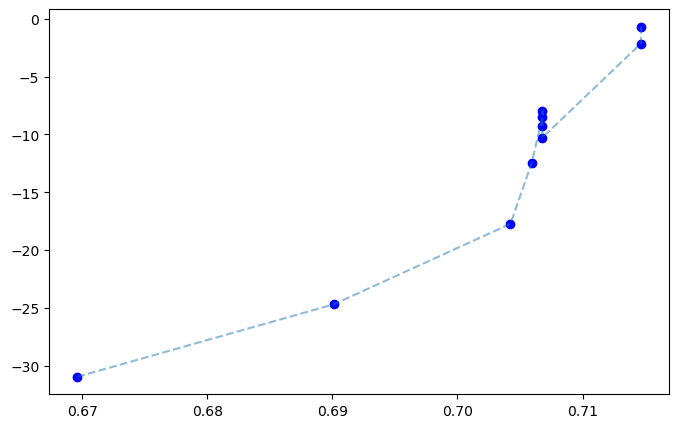

In [32]:
plot_deviation_per_sample(df, ground_truth_instability, 25, importance_scores=importance_values, sequence_list= sequence_list, step_percent=10)

Spearman correlation: -0.32218993815043423


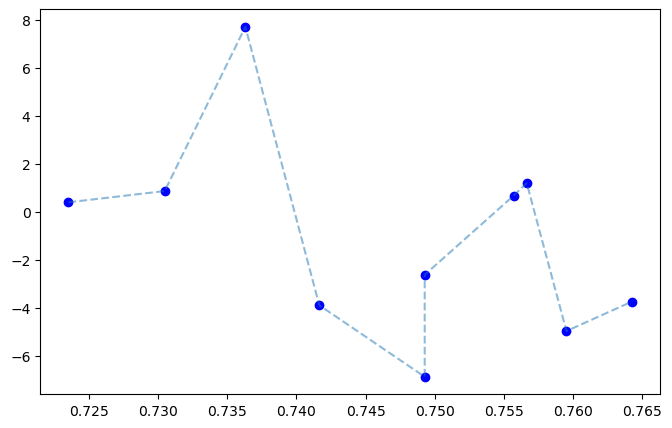

In [33]:
plot_deviation_per_sample(df, ground_truth_instability, 107, importance_scores=importance_values, sequence_list= sequence_list, step_percent=10)

Spearman correlation: 0.39394240167285516


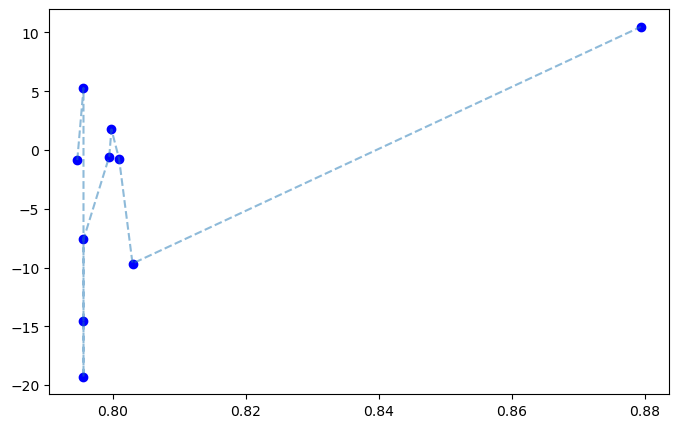

In [23]:
plot_deviation_per_sample(df, ground_truth_instability, 9, importance_scores=importance_values, sequence_list= sequence_list, step_percent=10)